<a href="https://colab.research.google.com/github/contatowillian/fiap/blob/main/EadFiap_Fase2_projeto2_novo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Sistema de Otimização de Rotas via Algoritmos Genéticos


Vamos começar a implementar o sistema de otimização de rotas utilizando algoritmos genéticos. O objetivo é resolver um problema similar ao Caixeiro Viajante (TSP) ou ao Problema de Roteamento de Veículos (VRP) para a distribuição de medicamentos e insumos hospitalares. A ideia é encontrar a rota mais eficiente considerando diversas restrições.

In [ ]:
import random # Para operações aleatórias, como mutação e crossover
import math   # Para cálculos matemáticos, como distância euclidiana

# --- Definição do Problema: Localizações e Distâncias ---

# Vamos simular algumas unidades hospitalares e pontos de entrega domiciliar como 'cidades'
# Cada 'cidade' terá suas coordenadas (latitude, longitude).
# Usaremos IDs numéricos para as cidades.

# A variável 'cidades' será definida e atualizada na seção de restrições (2.1).
# A função de distância precisa poder acessá-la.

# Função para calcular a distância entre duas cidades usando a fórmula de Haversine (para coordenadas geográficas)
def calcular_distancia(cidade1_id, cidade2_id):
    # Obter as coordenadas das duas cidades a partir do dicionário 'cidades'
    coord_cidade1 = cidades[cidade1_id]['coordenadas']
    coord_cidade2 = cidades[cidade2_id]['coordenadas']

    lat1, lon1 = math.radians(coord_cidade1[0]), math.radians(coord_cidade1[1])
    lat2, lon2 = math.radians(coord_cidade2[0]), math.radians(coord_cidade2[1])

    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1

    a = math.sin(delta_lat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(delta_lon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    raio_terra_km = 6371 # Raio médio da Terra em quilômetros
    distancia = raio_terra_km * c
    return distancia

# Os exemplos de uso da função de distância serão atualizados após a definição de 'cidades' na próxima seção.
# Para evitar erros de NameError, vamos remover os prints de exemplo daqui e adicioná-los após a definição.

# --- Capacidade e Autonomia do Veículo ---
capacidade_veiculo_max = 20  # Ex: 20 unidades de volume/peso
autonomia_veiculo_max = 380  # Ex: 180 km de autonomia

# --- Função de Aptidão com Restrições (para o AG VRP) ---
def calcular_aptidao_com_restricoes(cromossomo_vrp):
    custo_total_frota = 0
    cidades_visitadas_total = set() # Para verificar se todas as cidades foram visitadas

    # Itera sobre cada rota individual dentro do cromossomo VRP
    for rota_veiculo in cromossomo_vrp:
        distancia_total_veiculo = 0
        volume_carga_atual_veiculo = 0
        penalidade_capacidade_veiculo = 0
        penalidade_autonomia_veiculo = 0
        penalidade_prioridade_veiculo = 0

        # Garante que a rota tenha pelo menos o depósito de partida e retorno
        if len(rota_veiculo) < 2:
            custo_total_frota += 1000000 # Penalidade muito alta para rotas inviáveis/vazias
            continue

        # Adiciona o depósito ao conjunto de cidades visitadas, se for o início de uma rota
        if rota_veiculo[0] == 0:
            cidades_visitadas_total.add(0)

        # Calcula o custo para a rota deste veículo
        for i in range(len(rota_veiculo) - 1):
            cidade_atual_id = rota_veiculo[i]
            proxima_cidade_id = rota_veiculo[i+1]

            # Soma a distância percorrida entre as cidades
            distancia_trecho = calcular_distancia(cidade_atual_id, proxima_cidade_id)
            distancia_total_veiculo += distancia_trecho

            # Se não estiver no depósito (ponto de partida/retorno), atualiza a carga e penalidades
            if proxima_cidade_id != 0:
                cidades_visitadas_total.add(proxima_cidade_id)
                volume_carga_atual_veiculo += cidades[proxima_cidade_id]['volume_carga']
                # Penalidade existente por ter carga de alta prioridade
                penalidade_prioridade_veiculo += (cidades[proxima_cidade_id]['prioridade'] + 1) * cidades[proxima_cidade_id]['volume_carga'] * 10

            # Penalidade por exceder a capacidade do veículo
            if volume_carga_atual_veiculo > capacidade_veiculo_max:
                penalidade_capacidade_veiculo += (volume_carga_atual_veiculo - capacidade_veiculo_max) * 100

        # Novo: Penalidade por ordem de prioridade
        # Garante que cidades de maior prioridade sejam entregues ANTES de cidades de menor prioridade dentro da mesma rota.
        cidades_no_trecho = [c_id for c_id in rota_veiculo if c_id != 0]
        for idx in range(len(cidades_no_trecho) - 1):
            cidade_anterior_id = cidades_no_trecho[idx]
            cidade_posterior_id = cidades_no_trecho[idx + 1]

            prioridade_anterior = cidades[cidade_anterior_id]['prioridade']
            prioridade_posterior = cidades[cidade_posterior_id]['prioridade']

            # Se uma cidade de menor prioridade for visitada antes de uma de maior prioridade (no mesmo veículo)
            if prioridade_anterior < prioridade_posterior:
                penalidade_prioridade_veiculo += 500 * (prioridade_posterior - prioridade_anterior) # Penalidade maior se a diferença de prioridade for grande

        # Penalidade por exceder a autonomia do veículo (aplicada ao total do veículo)
        if distancia_total_veiculo > autonomia_veiculo_max:
            penalidade_autonomia_veiculo += (distancia_total_veiculo - autonomia_veiculo_max) * 50

        # Soma o custo deste veículo ao custo total da frota
        custo_total_frota += distancia_total_veiculo + penalidade_capacidade_veiculo + penalidade_autonomia_veiculo + penalidade_prioridade_veiculo

    # Penalidade adicional se nem todas as cidades de entrega foram visitadas
    # Exclui o depósito (ID 0) da lista de cidades a serem visitadas para esta verificação.
    pontos_necessarios = set(c for c in cidades.keys() if c != 0)
    if not pontos_necessarios.issubset(cidades_visitadas_total):
        custo_total_frota += 1000000 * len(pontos_necessarios - cidades_visitadas_total) # Grande penalidade para cidades não visitadas

    # A aptidão é o inverso do custo total da frota
    if custo_total_frota == 0:
        aptidao = float('inf')
    else:
        aptidao = 1 / custo_total_frota

    return aptidao, custo_total_frota

## 2. Incorporação de Restrições Realistas

Para tornar o modelo de otimização de rotas mais útil para um sistema hospitalar, precisamos incluir restrições que simulem situações reais. Vamos começar com prioridades de entrega e capacidade de carga dos veículos.

In [ ]:
# --- 2.1 Atualização da Estrutura de Cidades com Restrições ---

# Vamos adicionar novas propriedades às 'cidades' para incluir:
# - 'prioridade': (0 = baixa, 1 = média, 2 = alta) - pode influenciar na penalidade da aptidão.
# - 'volume_carga': O volume ou peso dos itens a serem entregues neste ponto.

# Atualizando o dicionário 'cidades' com novas informações (coordenadas reais da Grande São Paulo)
# As coordenadas são aproximadas para o centro de cada cidade.
cidades = {
    0: {'nome': 'Hospital Central (São Paulo)', 'coordenadas': (-23.5505, -46.6333), 'prioridade': 0, 'volume_carga': 0}, # Depósito - São Paulo Centro
    1: {'nome': 'Osasco', 'coordenadas': (-23.5323, -46.7919), 'prioridade': 1, 'volume_carga': 5},
    2: {'nome': 'Guarulhos', 'coordenadas': (-23.4659, -46.5332), 'prioridade': 2, 'volume_carga': 2}, # Medicamento crítico
    3: {'nome': 'São Caetano do Sul', 'coordenadas': (-23.6234, -46.5517), 'prioridade': 1, 'volume_carga': 3},
    4: {'nome': 'São Bernardo do Campo', 'coordenadas': (-23.6934, -46.5659), 'prioridade': 0, 'volume_carga': 7},
    5: {'nome': 'Diadema', 'coordenadas': (-23.6874, -46.6190), 'prioridade': 1, 'volume_carga': 6},
    6: {'nome': 'Taboão da Serra', 'coordenadas': (-23.6010, -46.7684), 'prioridade': 0, 'volume_carga': 4},
    7: {'nome': 'Embu das Artes', 'coordenadas': (-23.6559, -46.8525), 'prioridade': 1, 'volume_carga': 5},
    8: {'nome': 'Arujá', 'coordenadas': (-23.4079, -46.3312), 'prioridade': 2, 'volume_carga': 2},
    9: {'nome': 'Suzano', 'coordenadas': (-23.5458, -46.3117), 'prioridade': 0, 'volume_carga': 7}
}

# Número total de cidades/pontos de entrega
numero_cidades = len(cidades)

# Exemplo de uso da função de distância com as novas cidades
print(f"Distância entre {cidades[0]['nome']} e {cidades[1]['nome']}: {calcular_distancia(0, 1):.2f} km")
print(f"Distância entre {cidades[2]['nome']} e {cidades[4]['nome']}: {calcular_distancia(2, 4):.2f} km")
print(f"Distância entre {cidades[0]['nome']} e {cidades[5]['nome']}: {calcular_distancia(0, 5):.2f} km")
print(f"Distância entre {cidades[7]['nome']} e {cidades[9]['nome']}: {calcular_distancia(7, 9):.2f} km")

Distância entre Hospital Central (São Paulo) e Osasco: 16.29 km
Distância entre Guarulhos e São Bernardo do Campo: 25.52 km
Distância entre Hospital Central (São Paulo) e Diadema: 15.29 km
Distância entre Embu das Artes e Suzano: 56.45 km


In [ ]:
import openai
# Remover a importação de time, pois os sleeps serão removidos
# import time # Para adicionar pausas entre chamadas da API

\### 1.1 Representação Genética e Função Fitness

Nesta seção, vamos definir como uma rota será representada (o 'cromossomo' no algoritmo genético) e como a 'aptidão' de cada rota será calculada. A aptidão será inversamente proporcional à distância total percorrida pela rota, ou seja, rotas mais curtas terão maior aptidão.

In [ ]:
# --- 1.1.1 Representação Genética (Cromossomo para VRP) ---

# Para o VRP, um cromossomo precisa representar rotas para MÚLTIPLOS veículos.
# Uma forma comum é usar um 'separador' (delimiter) no cromossomo que indica o fim de uma rota
# e o início da próxima para outro veículo. Por exemplo: [0, 1, 2, 0, 3, 4, 0, 5, 6, 0]
# Onde '0' é o depósito, e cada '0' subsequente (não o inicial) atua como um separador.
# Ou, podemos usar uma representação de lista de listas, onde cada sublista
# começa e termina no depósito (0).
# Vamos optar por uma representação de lista de listas para maior clareza, onde cada sublista
# começa e termina no depósito (0).

# Número de veículos disponíveis (parâmetro para VRP)
numero_veiculos = 2 # Exemplo: 2 veículos

# Função para criar um cromossomo inicial (rotas aleatórias para múltiplos veículos)
def criar_cromossomo_aleatorio_vrp():
    pontos_de_entrega = list(cidades.keys()) # Obtém todos os IDs das cidades
    pontos_de_entrega.remove(0) # Remove o Hospital Central (depósito)
    random.shuffle(pontos_de_entrega) # Embaralha os pontos de entrega

    cromossomo_vrp = []
    # Divide os pontos de entrega entre os veículos o mais uniformemente possível
    for i in range(numero_veiculos):
        cromossomo_vrp.append([]) # Adiciona uma rota vazia para cada veículo

    # Distribui os pontos de entrega embaralhados entre os veículos
    for i, ponto in enumerate(pontos_de_entrega):
        veiculo_idx = i % numero_veiculos
        cromossomo_vrp[veiculo_idx].append(ponto)

    # Adiciona o depósito no início e no fim de cada rota de veículo
    for i in range(numero_veiculos):
        cromossomo_vrp[i] = [0] + cromossomo_vrp[i] + [0]
        # Garante que, se uma rota estiver vazia, ela ainda tenha [0, 0]
        if len(cromossomo_vrp[i]) == 1: # Se só tinha [0]
            cromossomo_vrp[i].append(0)

    return cromossomo_vrp

# Exemplo de cromossomo VRP (rotas aleatórias para múltiplos veículos)
rota_vrp_exemplo = criar_cromossomo_aleatorio_vrp()
print(f"Exemplo de cromossomo VRP (rotas aleatórias para {numero_veiculos} veículos): {rota_vrp_exemplo}")

# --- 1.1.2 Função Fitness (Função de Aptidão) ---

# A função fitness avalia quão 'boa' é uma rota. Para o TSP, rotas mais curtas são melhores.
# Portanto, a aptidão será o inverso da distância total da rota.
# Para VRP, calcula a soma das distâncias de todas as sub-rotas.
def calcular_aptidao(cromossomo_vrp):
    distancia_total_frota = 0
    for rota_veiculo in cromossomo_vrp:
        distancia_total_rota_veiculo = 0
        for i in range(len(rota_veiculo) - 1):
            cidade_atual_id = rota_veiculo[i]
            proxima_cidade_id = rota_veiculo[i+1]
            distancia_total_rota_veiculo += calcular_distancia(cidade_atual_id, proxima_cidade_id)
        distancia_total_frota += distancia_total_rota_veiculo

    # A aptidão é o inverso da distância total da frota
    if distancia_total_frota == 0:
        aptidao = float('inf') # Caso improvável, mas para segurança
    else:
        aptidao = 1 / distancia_total_frota

    return aptidao, distancia_total_frota

Exemplo de cromossomo VRP (rotas aleatórias para 2 veículos): [[0, 9, 4, 6, 5, 8, 0], [0, 7, 3, 2, 1, 0]]


### 1.2 Operadores Genéticos

Os operadores genéticos são a espinha dorsal de qualquer algoritmo genético. Eles são responsáveis por criar novas gerações de soluções a partir das soluções existentes, simulando o processo de evolução natural.

*   **Seleção:** Escolhe os indivíduos mais 'aptos' da população atual para serem os 'pais' da próxima geração.
*   **Crossover (Cruzamento):** Combina material genético de dois pais para criar um ou mais 'filhos' (novas soluções).
*   **Mutação:** Introduz pequenas alterações aleatórias nos filhos para manter a diversidade genética e evitar que o algoritmo fique preso em mínimos locais.

In [ ]:
# --- 1.2.1 Operador de Seleção (Seleção por Roleta) ---

# A seleção por roleta escolhe indivíduos com base em sua aptidão:
# quanto maior a aptidão, maior a chance de ser selecionado.
def selecao_roleta(populacao, aptidoes):
    # A soma total das aptidões de todos os indivíduos na população
    soma_total_aptidoes = sum(aptidoes)

    # Se a soma das aptidões for zero (todos têm aptidão 0), escolhe aleatoriamente para evitar erro.
    if soma_total_aptidoes == 0:
        return random.choice(populacao)

    # Gera um número aleatório entre 0 e a soma total das aptidões
    ponto_sorteio = random.uniform(0, soma_total_aptidoes)

    aptidao_acumulada = 0
    # Itera sobre a população, somando as aptidões até encontrar o indivíduo
    # que corresponde ao ponto sorteado na roleta.
    for i, individuo in enumerate(populacao):
        aptidao_acumulada += aptidoes[i]
        if aptidao_acumulada >= ponto_sorteio:
            return individuo

# --- 1.2.2 Operador de Crossover (Cruzamento por Ordem - OX1) para VRP ---
# Este operador será adaptado para a representação de lista de listas (VRP)
def crossover_vrp_simple(pai1_vrp, pai2_vrp):
    filho_vrp = []
    # Inicializa o filho com rotas vazias
    for _ in range(numero_veiculos):
        filho_vrp.append([])

    # Escolhe um ponto de corte aleatório para as rotas
    # Por simplicidade, vamos trocar uma rota inteira entre os pais
    idx_rota_trocada = random.randint(0, numero_veiculos - 1)

    # O filho recebe uma rota de pai1 e o restante de pai2 (e vice-versa para o segundo filho, se implementado)
    filho_vrp = list(pai2_vrp) # Começa com todas as rotas do pai2
    filho_vrp[idx_rota_trocada] = list(pai1_vrp[idx_rota_trocada]) # Substitui uma rota pela do pai1

    # Lidar com cidades duplicadas e não visitadas
    cidades_visitadas_no_filho = set()
    for rota in filho_vrp:
        for cidade_id in rota:
            if cidade_id != 0:
                cidades_visitadas_no_filho.add(cidade_id)

    pontos_de_entrega_originais = set(c for c in cidades.keys() if c != 0)
    cidades_faltantes = pontos_de_entrega_originais - cidades_visitadas_no_filho

    # Para simplificar, as cidades faltantes são adicionadas aleatoriamente a rotas existentes.
    # Em um VRP real, isso exigiria um reparo mais sofisticado.
    for cidade_id in cidades_faltantes:
        rota_aleatoria_idx = random.randint(0, numero_veiculos - 1)
        # Insere a cidade faltante antes do depósito de retorno
        filho_vrp[rota_aleatoria_idx].insert(len(filho_vrp[rota_aleatoria_idx]) - 1, cidade_id)

    return filho_vrp

# --- 1.2.3 Operador de Mutação (Troca de Swap) para VRP ---
# Este operador será adaptado para a representação de lista de listas (VRP)
def mutacao_vrp_simple(cromossomo_vrp, taxa_mutacao=0.01):
    cromossomo_mutado = [list(rota) for rota in cromossomo_vrp] # Cria uma cópia profunda

    if random.random() < taxa_mutacao:
        # Escolhe uma rota aleatória para mutar
        idx_rota_mutar = random.randint(0, numero_veiculos - 1)
        rota_para_mutar = cromossomo_mutado[idx_rota_mutar]

        # Aplica a mutação por troca (swap) dentro dessa rota
        if len(rota_para_mutar) > 3: # Garante que haja pelo menos 2 pontos para trocar (além dos depósitos)
            # Escolhe dois índices aleatórios dentro da parte mutável (excluindo o depósito inicial e final)
            idx1, idx2 = random.sample(range(1, len(rota_para_mutar) - 1), 2)

            # Troca as posições dos elementos nesses índices
            rota_para_mutar[idx1], rota_para_mutar[idx2] = rota_para_mutar[idx2], rota_para_mutar[idx1]

    return cromossomo_mutado

# Exemplo de uso dos operadores
print("\n--- Exemplos dos Operadores Genéticos para VRP ---")

# Gerar população de exemplo para seleção
populacao_exemplo_vrp = [criar_cromossomo_aleatorio_vrp() for _ in range(5)]
aptidoes_exemplo_vrp = [calcular_aptidao_com_restricoes(c)[0] for c in populacao_exemplo_vrp]

print(f"População VRP exemplo: {populacao_exemplo_vrp}")
print(f"Aptidões VRP exemplo: {[f'{a:.4f}' for a in aptidoes_exemplo_vrp]}")

pai_selecionado_vrp = selecao_roleta(populacao_exemplo_vrp, aptidoes_exemplo_vrp)
print(f"Pai VRP selecionado por roleta: {pai_selecionado_vrp}")

# Criar dois pais para crossover VRP
pai1_crossover_vrp = criar_cromossomo_aleatorio_vrp()
pai2_crossover_vrp = criar_cromossomo_aleatorio_vrp()
print(f"\nPai 1 para crossover VRP: {pai1_crossover_vrp}")
print(f"Pai 2 para crossover VRP: {pai2_crossover_vrp}")
filho_gerado_vrp = crossover_vrp_simple(pai1_crossover_vrp, pai2_crossover_vrp)
print(f"Filho gerado por crossover VRP: {filho_gerado_vrp}")

# Exemplo de mutação VRP
cromossomo_para_mutar_vrp = criar_cromossomo_aleatorio_vrp()
print(f"\nCromossomo VRP antes da mutação: {cromossomo_para_mutar_vrp}")
cromossomo_apos_mutacao_vrp = mutacao_vrp_simple(cromossomo_para_mutar_vrp, taxa_mutacao=1.0) # Força mutação para demonstração
print(f"Cromossomo VRP após mutação (taxa=1.0): {cromossomo_apos_mutacao_vrp}")


--- Exemplos dos Operadores Genéticos para VRP ---
População VRP exemplo: [[[0, 2, 4, 9, 3, 7, 0], [0, 5, 8, 6, 1, 0]], [[0, 9, 1, 3, 7, 6, 0], [0, 2, 8, 4, 5, 0]], [[0, 3, 8, 5, 1, 2, 0], [0, 9, 4, 7, 6, 0]], [[0, 5, 7, 1, 6, 3, 0], [0, 4, 9, 8, 2, 0]], [[0, 5, 2, 8, 1, 7, 0], [0, 9, 4, 6, 3, 0]]]
Aptidões VRP exemplo: ['0.0003', '0.0004', '0.0003', '0.0003', '0.0005']
Pai VRP selecionado por roleta: [[0, 9, 1, 3, 7, 6, 0], [0, 2, 8, 4, 5, 0]]

Pai 1 para crossover VRP: [[0, 8, 4, 7, 3, 6, 0], [0, 5, 2, 9, 1, 0]]
Pai 2 para crossover VRP: [[0, 6, 7, 2, 4, 3, 0], [0, 9, 8, 1, 5, 0]]
Filho gerado por crossover VRP: [[0, 6, 7, 2, 4, 3, 8, 0], [0, 5, 2, 9, 1, 0]]

Cromossomo VRP antes da mutação: [[0, 9, 4, 2, 1, 7, 0], [0, 6, 5, 8, 3, 0]]
Cromossomo VRP após mutação (taxa=1.0): [[0, 9, 4, 2, 1, 7, 0], [0, 8, 5, 6, 3, 0]]


### 1.3 Algoritmo Genético Principal

Agora que temos a representação, a função fitness e os operadores genéticos, podemos montar o algoritmo genético completo. Ele seguirá um ciclo iterativo:

1.  **Inicialização:** Cria uma população inicial de rotas aleatórias.
2.  **Avaliação:** Calcula a aptidão de cada rota na população.
3.  **Seleção:** Escolhe os indivíduos mais aptos para serem os pais da próxima geração.
4.  **Crossover:** Combina os pais para criar novos indivíduos (filhos).
5.  **Mutação:** Introduz pequenas variações nos filhos.
6.  **Nova Geração:** Substitui a população antiga pela nova geração de filhos (e, opcionalmente, mantém os melhores pais - elitismo).
7.  **Repetição:** O ciclo se repete por um número definido de gerações ou até que um critério de parada seja atingido.

In [ ]:
# --- 1.3.1 Algoritmo Genético Principal (para VRP) ---

def algoritmo_genetico_vrp(
    tamanho_populacao,
    numero_geracoes,
    taxa_mutacao,
    taxa_crossover
):
    # Inicializa a população com cromossomos VRP (lista de listas)
    populacao = [criar_cromossomo_aleatorio_vrp() for _ in range(tamanho_populacao)]

    melhor_cromossomo_vrp = None
    melhor_custo = float('inf') # Agora vamos rastrear o custo (distância + penalidade)
    historico_melhor_custo = []

    print("Iniciando algoritmo genético VRP com restrições de capacidade, autonomia e PRIORIDADE...")

    for geracao in range(numero_geracoes):
        # 1. Avaliação da população usando a função de aptidão com restrições para VRP
        aptidoes = []
        custos = [] # Agora armazenamos o custo total (distância + penalidade)
        for cromossomo_vrp_individuo in populacao:
            aptidao, custo = calcular_aptidao_com_restricoes(cromossomo_vrp_individuo) # Usa a função com restrições para VRP
            aptidoes.append(aptidao)
            custos.append(custo)

        # Encontra o melhor indivíduo da geração atual (o de menor custo)
        indice_melhor_atual = custos.index(min(custos))
        custo_atual_melhor = custos[indice_melhor_atual]

        # Atualiza o melhor cromossomo VRP global, se encontrado um melhor (menor custo)
        if custo_atual_melhor < melhor_custo:
            melhor_custo = custo_atual_melhor
            melhor_cromossomo_vrp = populacao[indice_melhor_atual]

        historico_melhor_custo.append(melhor_custo)

        # Imprime o progresso a cada X gerações
        if (geracao + 1) % 10 == 0 or geracao == 0:
            print(f"Geração {geracao + 1}/{numero_geracoes}: Melhor Custo = {melhor_custo:.2f}")

        # 2. Criação da próxima geração
        nova_populacao = []

        # Elitismo: Mantém o melhor indivíduo da geração anterior diretamente na próxima
        # Adiciona uma cópia profunda para evitar referência, pois é uma lista de listas
        nova_populacao.append([list(rota) for rota in melhor_cromossomo_vrp])

        # Preenche o restante da nova população
        while len(nova_populacao) < tamanho_populacao:
            # 3. Seleção de pais
            pai1_vrp = selecao_roleta(populacao, aptidoes)
            pai2_vrp = selecao_roleta(populacao, aptidoes)

            # 4. Crossover para VRP
            filho_vrp = None
            if random.random() < taxa_crossover:
                filho_vrp = crossover_vrp_simple(pai1_vrp, pai2_vrp)
            else:
                # Se não houver crossover, um dos pais é copiado diretamente (cópia profunda)
                filho_vrp = [list(rota) for rota in random.choice([pai1_vrp, pai2_vrp])]

            # 5. Mutação para VRP
            filho_mutado_vrp = mutacao_vrp_simple(filho_vrp, taxa_mutacao)
            nova_populacao.append(filho_mutado_vrp)

        # 6. Atualiza a população para a próxima geração
        populacao = nova_populacao

    print("Algoritmo genético VRP concluído!")

    # Recalcular a distância pura para o melhor cromossomo VRP final
    _, distancia_pura_final = calcular_aptidao(melhor_cromossomo_vrp)

    return melhor_cromossomo_vrp, distancia_pura_final, melhor_custo, historico_melhor_custo

# --- Parâmetros do Algoritmo Genético ---
tamanho_populacao = 850
numero_geracoes = 100
taxa_crossover = 0.3 # % de chance de crossover (ajustado para VRP)
taxa_mutacao = 0.4   # % de chance de mutação para cada indivíduo

# Executa o algoritmo com a nova função fitness para VRP
melhor_rota_final_restricoes, menor_distancia_pura, menor_custo_final, historico_custos = algoritmo_genetico_vrp(
    tamanho_populacao,
    numero_geracoes,
    taxa_mutacao,
    taxa_crossover
)

print("\n--- Resultados Finais (com Restrições e Prioridade para VRP) ---")
print(f"Melhor cromossomo VRP encontrado (rotas): {melhor_rota_final_restricoes}")
print(f"Menor distância pura total percorrida pela frota: {menor_distancia_pura:.2f} km")
print(f"Menor custo total da frota (distância + penalidades): {menor_custo_final:.2f}")

# Para visualização, vamos imprimir os nomes das cidades em cada rota da frota
print("Rotas em nomes:")
for i, rota_veiculo in enumerate(melhor_rota_final_restricoes):
    nome_rotas_veiculo = [cidades[cidade_id]['nome'] for cidade_id in rota_veiculo]
    print(f"  Veículo {i+1}: {' -> '.join(nome_rotas_veiculo)}")

Iniciando algoritmo genético VRP com restrições de capacidade, autonomia e PRIORIDADE...
Geração 1/100: Melhor Custo = 1193.55
Geração 10/100: Melhor Custo = 1143.65
Geração 20/100: Melhor Custo = 1095.46
Geração 30/100: Melhor Custo = 1095.46
Geração 40/100: Melhor Custo = 1095.46
Geração 50/100: Melhor Custo = 1095.46
Geração 60/100: Melhor Custo = 1095.46
Geração 70/100: Melhor Custo = 1095.46
Geração 80/100: Melhor Custo = 1095.46
Geração 90/100: Melhor Custo = 1095.46
Geração 100/100: Melhor Custo = 1095.46
Algoritmo genético VRP concluído!

--- Resultados Finais (com Restrições e Prioridade para VRP) ---
Melhor cromossomo VRP encontrado (rotas): [[0, 2, 3, 5, 7, 1, 0], [0, 8, 9, 4, 6, 0]]
Menor distância pura total percorrida pela frota: 215.46 km
Menor custo total da frota (distância + penalidades): 1095.46
Rotas em nomes:
  Veículo 1: Hospital Central (São Paulo) -> Guarulhos -> São Caetano do Sul -> Diadema -> Embu das Artes -> Osasco -> Hospital Central (São Paulo)
  Veículo 

### 1.3.2 Visualização da Evolução do Melhor Custo por Geração

Podemos plotar o histórico do melhor custo encontrado em cada geração para observar a convergência do algoritmo genético.

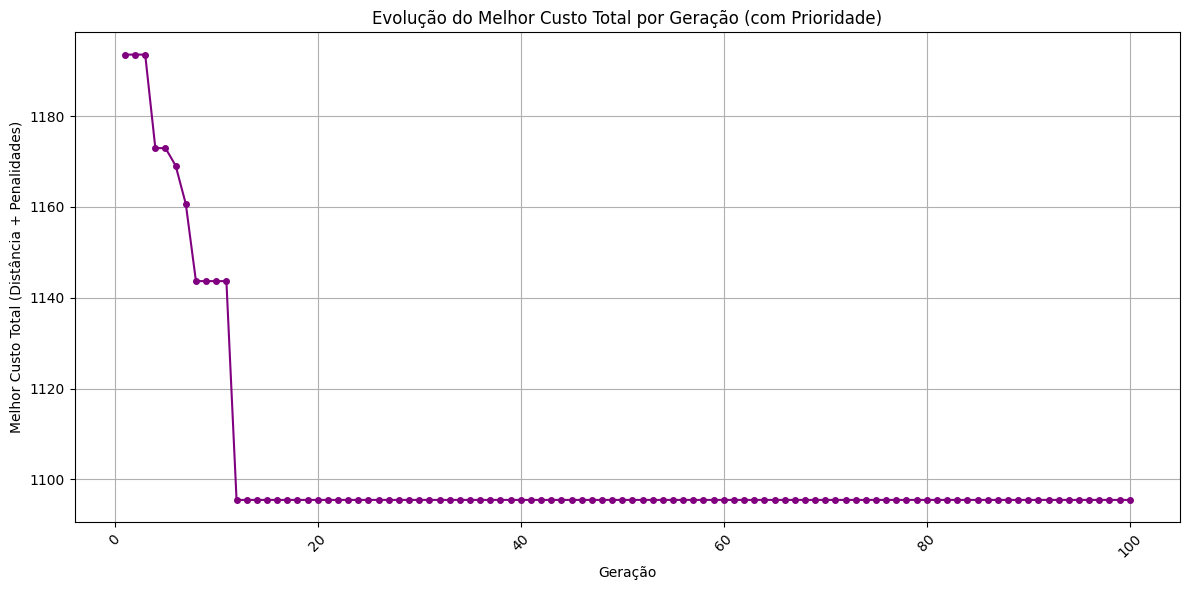

In [ ]:
# Importar matplotlib para a plotagem, caso ainda não tenha sido importado
import matplotlib.pyplot as plt

# Criar um gráfico da evolução do melhor custo
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(historico_custos) + 1), historico_custos, marker='o', linestyle='-', markersize=4, color='purple')
plt.title('Evolução do Melhor Custo Total por Geração (com Prioridade)')
plt.xlabel('Geração')
plt.ylabel('Melhor Custo Total (Distância + Penalidades)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 1.4 Visualização da Rota Otimizada

Uma parte importante do sistema é a capacidade de visualizar as rotas otimizadas. Isso ajuda na compreensão e verificação dos resultados do algoritmo genético. Vamos plotar as cidades e a melhor rota encontrada em um gráfico de dispersão.

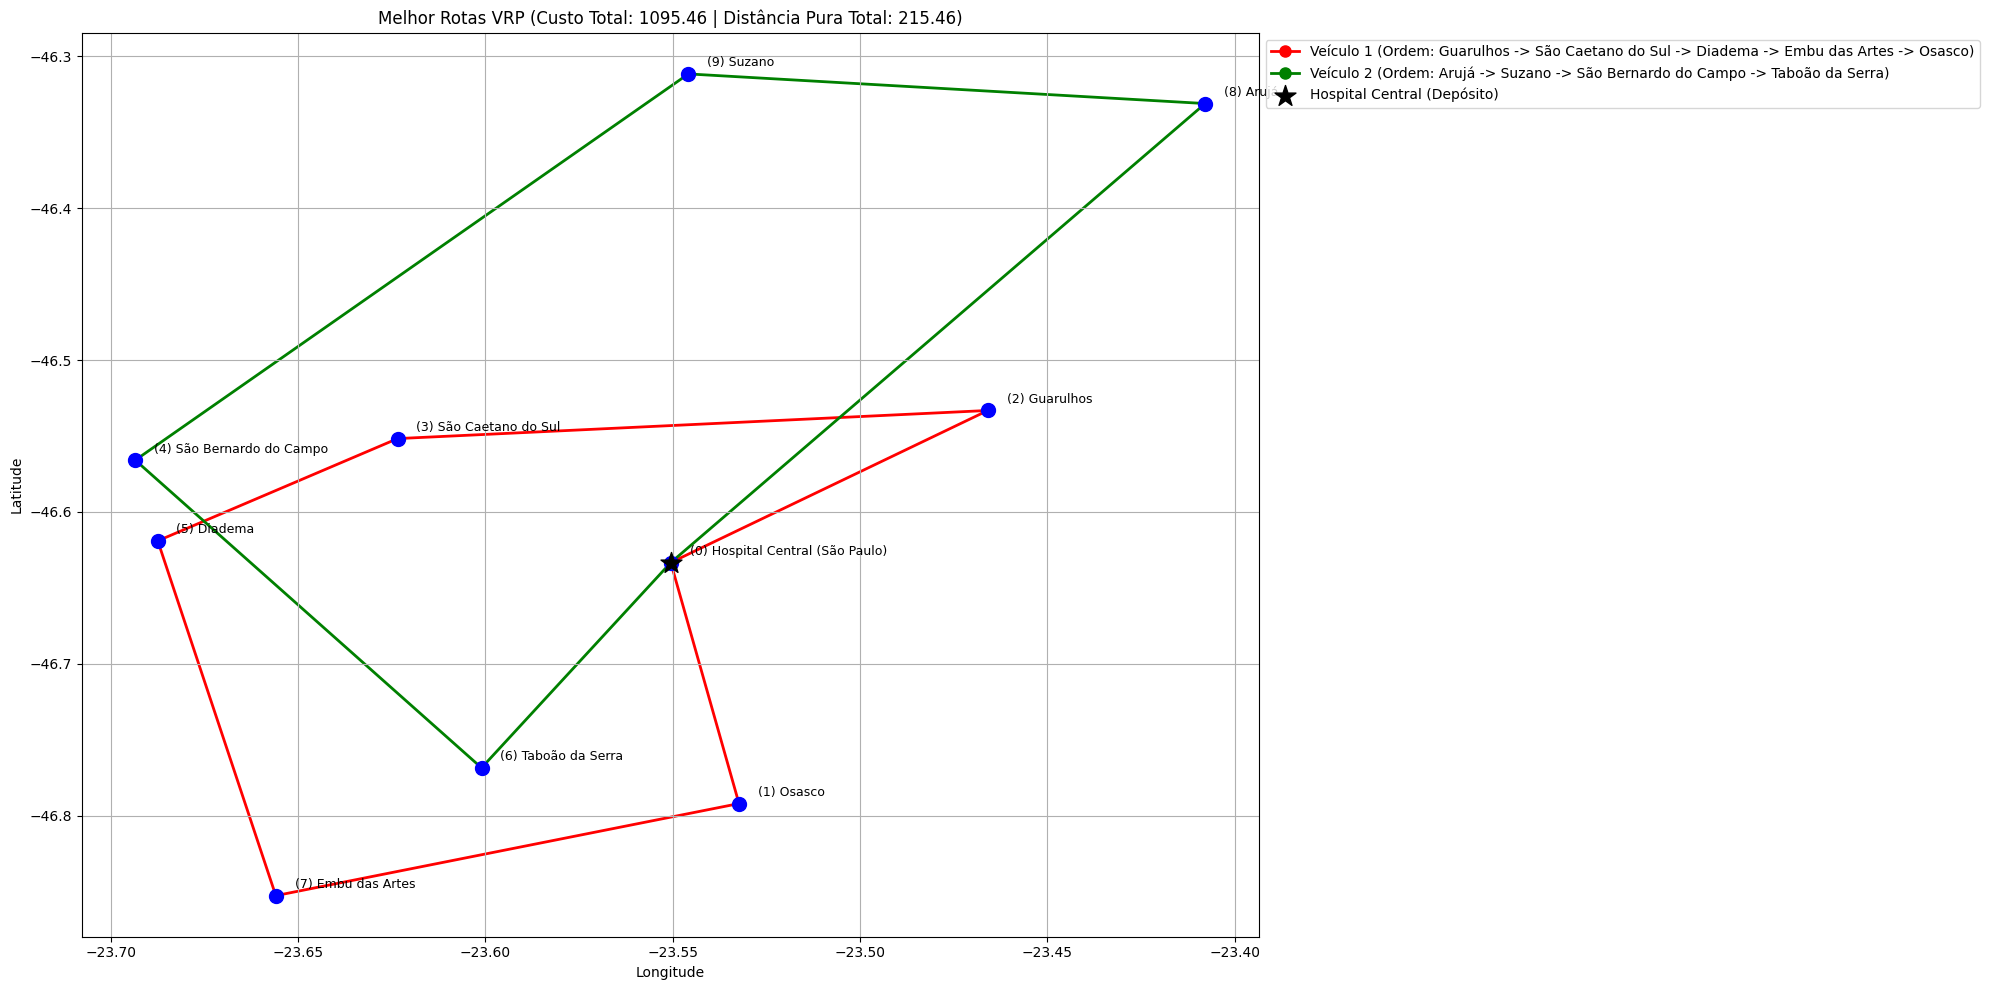

In [ ]:
# Importar biblioteca para plotagem
import matplotlib.pyplot as plt # Para criar gráficos e visualizações

# --- 1.4.1 Função para Visualizar a Rota (para VRP) ---

def visualizar_rota_vrp(cromossomo_vrp, cidades_data, titulo="Rotas Otimizadas VRP"):
    plt.figure(figsize=(20, 10)) # Define o tamanho da figura para melhor visualização

    # Extrair coordenadas e nomes das cidades
    x_coords = [cidades_data[id_cidade]['coordenadas'][0] for id_cidade in cidades_data]
    y_coords = [cidades_data[id_cidade]['coordenadas'][1] for id_cidade in cidades_data]
    nomes = [cidades_data[id_cidade]['nome'] for id_cidade in cidades_data]

    # Plotar todas as cidades como pontos
    plt.scatter(x_coords, y_coords, color='blue', s=100, zorder=5) # s é o tamanho do ponto, zorder garante que os pontos fiquem na frente

    # Anotar os nomes das cidades ao lado dos pontos
    for i, nome in enumerate(nomes):
        plt.annotate(f"({i}) {nome}", (x_coords[i] + 0.005, y_coords[i] + 0.005), fontsize=9)

    # Cores para as diferentes rotas dos veículos
    cores = ['red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'cyan', 'magenta', 'lime']

    # Plotar cada rota de veículo
    for i, rota_veiculo in enumerate(cromossomo_vrp):
        # Extrair os nomes das cidades na ordem de visitação (excluindo o depósito)
        cidades_na_ordem = [cidades_data[c_id]['nome'] for c_id in rota_veiculo if c_id != 0]
        ordem_visitacao_str = " -> ".join(cidades_na_ordem)

        rota_x = [cidades_data[cidade_id]['coordenadas'][0] for cidade_id in rota_veiculo]
        rota_y = [cidades_data[cidade_id]['coordenadas'][1] for cidade_id in rota_veiculo]
        plt.plot(rota_x, rota_y, color=cores[i % len(cores)], linestyle='-', linewidth=2, marker='o', markersize=8, zorder=1, label=f'Veículo {i+1} (Ordem: {ordem_visitacao_str})')

    # Marcar o ponto de partida/depósito (Hospital Central) de forma diferente
    plt.scatter(cidades_data[0]['coordenadas'][0], cidades_data[0]['coordenadas'][1], color='black', s=250, marker='*', zorder=10, label='Hospital Central (Depósito)')

    plt.title(titulo) # Título do gráfico
    plt.xlabel("Longitude") # Rótulo do eixo X (usando Longitude para X)
    plt.ylabel("Latitude") # Rótulo do eixo Y (usando Latitude para Y)
    plt.grid(True) # Adiciona grade ao gráfico
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Mostra a legenda fora do gráfico para não sobrepor
    plt.tight_layout() # Ajusta o layout para evitar que a legenda se sobreponha ao gráfico
    plt.show() # Exibe o gráfico

# Visualizar a melhor rota VRP encontrada
visualizar_rota_vrp(melhor_rota_final_restricoes, cidades, f"Melhor Rotas VRP (Custo Total: {menor_custo_final:.2f} | Distância Pura Total: {menor_distancia_pura:.2f})")

### 1.5 Visualização da Rota Otimizada em Mapa Interativo (Google Maps-like)

Para uma compreensão ainda melhor da rota, vamos visualizá-la em um mapa interativo utilizando a biblioteca `folium`. Isso nos permitirá ver a rota sobrepujada em um mapa real, semelhante ao Google Maps.

In [ ]:
# Importar a biblioteca folium para criar mapas interativos
import folium

# --- 1.5.1 Função para Visualizar a Rota no Mapa com Folium (para VRP) ---

def visualizar_rota_mapa_vrp(cromossomo_vrp, cidades_data, titulo="Rotas Otimizadas VRP na Grande São Paulo"):
    # Calcular a latitude e longitude central para o mapa
    lat_central = cidades_data[0]['coordenadas'][0]
    lon_central = cidades_data[0]['coordenadas'][1]

    # Criar um mapa folium centrado na área de interesse
    m = folium.Map(location=[lat_central, lon_central], zoom_start=11) # Zoom inicial ajustado para SP

    # Adicionar marcador para o Hospital Central (Depósito)
    lat_depot, lon_depot = cidades_data[0]['coordenadas']
    folium.Marker(
        [lat_depot, lon_depot],
        popup=f"<b>{cidades_data[0]['nome']}</b><br>Depósito",
        icon=folium.Icon(color='black', icon='home', prefix='fa') # Using 'home' icon for depot
    ).add_to(m)

    # Cores para as diferentes rotas dos veículos
    cores = ['red', 'darkblue', 'green', 'purple', 'orange', 'darkgreen', 'cadetblue', 'darkred', 'lightgray', 'pink']

    # Desenhar cada rota de veículo no mapa e adicionar marcadores numerados
    for i, rota_veiculo in enumerate(cromossomo_vrp):
        pontos_rota = []
        ordem_visita = 0 # Reinicia a contagem para cada veículo
        cidades_para_tooltip = [] # Para o tooltip da linha, apenas os nomes das cidades de entrega

        for cidade_id in rota_veiculo:
            lat, lon = cidades_data[cidade_id]['coordenadas']
            pontos_rota.append([lat, lon])

            if cidade_id != 0: # Não numerar o depósito
                ordem_visita += 1
                nome = cidades_data[cidade_id]['nome']
                prioridade = cidades_data[cidade_id]['prioridade']
                volume = cidades_data[cidade_id]['volume_carga']
                cidades_para_tooltip.append(f"{nome}") # Add name for tooltip

                # Usar DivIcon para mostrar o número da ordem de visitação
                folium.Marker(
                    [lat, lon],
                    popup=f"<b>{nome}</b><br>Prioridade: {prioridade}<br>Volume: {volume}<br>Ordem de Visita: {ordem_visita}",
                    icon=folium.DivIcon(
                        icon_size=(20, 20),
                        icon_anchor=(10, 10), # Center the icon
                        html=f'<div style="font-size: 10pt; font-weight: bold; background-color: {cores[i % len(cores)]}; color: white; border-radius: 50%; width: 20px; height: 20px; text-align: center; line-height: 20px; border: 1px solid black;">{ordem_visita}</div>'
                    )
                ).add_to(m)

        # Construir o tooltip da linha
        tooltip_linha = f'Veículo {i+1}: {cidades_data[0]["nome"]} -> ' + ' -> '.join(cidades_para_tooltip) + f' -> {cidades_data[0]["nome"]}'
        folium.PolyLine(pontos_rota, color=cores[i % len(cores)], weight=3, opacity=0.7, tooltip=tooltip_linha).add_to(m)


    # Adicionar um título ao mapa, se necessário
    title_html = f'<h3 align="center" style="font-size:16px"><b>{titulo}</b></h3>'
    m.get_root().html.add_child(folium.Element(title_html))

    return m

# Visualizar a melhor rota VRP encontrada no mapa interativo
mapa_rota_vrp = visualizar_rota_mapa_vrp(melhor_rota_final_restricoes, cidades,
                                         f"Melhor Rotas VRP (Custo Total: {menor_custo_final:.2f} km | Distância Pura Total: {menor_distancia_pura:.2f} km) com Prioridade")

# Exibir o mapa
mapa_rota_vrp

## 2. Integração com LLMs para Geração de Instruções e Relatórios

Vamos utilizar uma LLM (Large Language Model) para enriquecer nosso sistema de otimização de rotas. Com uma LLM, podemos automatizar a geração de textos informativos e analíticos, como instruções para motoristas, relatórios de desempenho e sugestões de melhoria.

Para começar, você precisará configurar sua chave de API do Google Gemini. Se você ainda não tem uma, crie uma no Google AI Studio. Em seguida, armazene-a de forma segura no Gerenciador de Segredos do Colab (ícone de chave "🔑" no painel esquerdo), nomeando-a como `GOOGLE_API_KEY`. Depois, podemos configurar o SDK para acessá-la.

In [ ]:
# Importe o SDK Python
import google.generativeai as genai
# Usado para armazenar com segurança sua chave de API
from google.colab import userdata

GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

In [ ]:
# A autenticação do Hugging Face não é mais necessária, pois não estamos baixando um modelo local.

In [ ]:
gemini_model = genai.GenerativeModel('gemini-3.5-flash')


In [ ]:
# Instala as bibliotecas necessárias para usar modelos Hugging Face Transformers
!pip install -qqq -U transformers accelerate

# Para o modelo Gemma, pode ser necessário autenticação via Hugging Face Hub
# Se você encontrar erros de "token" ou "repositório privado", visite hf.co/settings/tokens
# from huggingface_hub import login
# login(token="hf_SEU_TOKEN_AQUI") # Substitua com seu token da Hugging Face

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 81.5 MB/s eta 0:00:00


In [ ]:
def generate_local_response(prompt_text):
    # gemini_model is already defined in cell 849df76d
    response = gemini_model.generate_content(prompt_text)
    return response.text

In [ ]:
# Atualiza a biblioteca google.generativeai para a versão mais recente
!pip install --upgrade google-generativeai

# IMPORTANTE: Após a atualização, você pode precisar reiniciar o ambiente de execução
# (Runtime -> Restart runtime) para que as mudanças tenham efeito.

### 2.1 Geração de Instruções Detalhadas para Motoristas

Podemos usar a LLM para transformar as rotas otimizadas em instruções claras e detalhadas para os motoristas, incluindo informações sobre prioridades e volumes de carga.

In [ ]:
def gerar_instrucoes_motorista(melhor_rota, cidades_data):
    instrucoes_gerais = []
    for i, rota_veiculo in enumerate(melhor_rota):
        instrucao_veiculo = f"\n--- Instruções para o Veículo {i+1} ---"
        instrucao_veiculo += f"\nPonto de Partida: {cidades_data[0]['nome']}\n"

        pontos_entrega_na_rota = [c_id for c_id in rota_veiculo if c_id != 0]

        if not pontos_entrega_na_rota:
            instrucao_veiculo += "Nenhuma entrega programada para este veículo, retornando ao depósito.\n"
        else:
            instrucao_veiculo += "Sequência de Entregas:\n"
            for j, cidade_id in enumerate(rota_veiculo):
                if cidade_id == 0 and j > 0 and j < len(rota_veiculo) -1:
                  continue # Skip intermediate depots in the instructions

                nome_cidade = cidades_data[cidade_id]['nome']
                prioridade = cidades_data[cidade_id]['prioridade']
                volume = cidades_data[cidade_id]['volume_carga']

                if cidade_id == 0:
                    if j == 0:
                        instrucao_veiculo += f"  - 1º: {nome_cidade} (Início da Rota)\n"
                    elif j == len(rota_veiculo) - 1:
                        instrucao_veiculo += f"  - Último: {nome_cidade} (Fim da Rota)\n"
                else:
                    instrucao_veiculo += f"  - {j}: {nome_cidade} (Prioridade: {prioridade}, Volume: {volume} unidades)\n"
        instrucoes_gerais.append(instrucao_veiculo)

    prompt_text = """
Com base nas seguintes rotas otimizadas para veículos de entrega de suprimentos hospitalares, gere instruções claras e concisas para cada motorista. Destaque a ordem das paradas, a prioridade da entrega (0=baixa, 1=média, 2=alta) e o volume da carga para cada ponto.

Rotas Otimizadas:
""" + "\n".join(instrucoes_gerais)

    # Usando o modelo LLM local para gerar a resposta
    response_content = generate_local_response(prompt_text)

    print("Instruções para os Motoristas:")
    print(response_content)

gerar_instrucoes_motorista(melhor_rota_final_restricoes, cidades)

Instruções para os Motoristas:
Aqui estão as instruções de rota claras e detalhadas para cada motorista, com as prioridades e volumes de carga destacados para facilitar a operação.

---

### **🚚 INSTRUÇÕES PARA O MOTORISTA - VEÍCULO 1**

*   **Ponto de Partida:** Hospital Central (São Paulo)
*   **Retorno:** Hospital Central (São Paulo)

#### **Sequência de Entregas:**

1.  **1ª Parada: Guarulhos**
    *   **Prioridade:** 🔥 **Alta (2)**
    *   **Volume:** 2 unidades
2.  **2ª Parada: São Caetano do Sul**
    *   **Prioridade:** ⚠️ **Média (1)**
    *   **Volume:** 3 unidades
3.  **3ª Parada: Diadema**
    *   **Prioridade:** ⚠️ **Média (1)**
    *   **Volume:** 6 unidades
4.  **4ª Parada: Embu das Artes**
    *   **Prioridade:** ⚠️ **Média (1)**
    *   **Volume:** 5 unidades
5.  **5ª Parada: Osasco**
    *   **Prioridade:** ⚠️ **Média (1)**
    *   **Volume:** 5 unidades

---

### **🚚 INSTRUÇÕES PARA O MOTORISTA - VEÍCULO 2**

*   **Ponto de Partida:** Hospital Central (São Paulo)
*  

### Verificando Modelos Disponíveis para Geração de Conteúdo

Para garantir que estamos utilizando um nome de modelo válido e que ele suporta a função `generateContent`, vamos listar os modelos disponíveis através da API.

In [ ]:
# Esta célula não é mais relevante para listar modelos OpenAI. Será mantida, mas não executará nada com o cliente OpenAI.
# print('Listando modelos disponíveis para `generateContent`:')
# for m in genai.list_models():
#   if 'generateContent' in m.supported_generation_methods:
#     print(m.name)
print('Para listar modelos OpenAI, você pode usar: openai_client.models.list()')

### 2.2 Criação de Relatórios Diários/Semanais

A LLM também pode ser utilizada para gerar resumos executivos ou relatórios detalhados sobre a eficiência das rotas, destacando a economia de tempo e recursos. Vamos criar um prompt que utilize os resultados do nosso AG para gerar um relatório.

In [ ]:
def gerar_relatorio_eficiencia(melhor_rota, menor_custo, menor_distancia, numero_veiculos, cidades_data):
    detalhes_rota = []
    for i, rota_veiculo in enumerate(melhor_rota):
        nomes_rota = [cidades_data[c_id]['nome'] for c_id in rota_veiculo]
        detalhes_rota.append(f"Veículo {i+1}: {' -> '.join(nomes_rota)}")

    prompt_text = f"""
Com base nos seguintes resultados de otimização de rotas para entrega de suprimentos hospitalares:

- Número de veículos utilizados: {numero_veiculos}
- Rotas Otimizadas: {'; '.join(detalhes_rota)}
- Menor Distância Pura Total da Frota: {menor_distancia:.2f} km
- Menor Custo Total da Frota (com penalidades): {menor_custo:.2f}

Por favor, gere um relatório diário de eficiência que inclua:
1. Um resumo da otimização e dos principais resultados.
2. Uma análise da economia de distância (se possível, comparando com uma abordagem não otimizada, embora aqui não tenhamos essa base).
3. Recomendações gerais para otimizações futuras ou observações sobre a eficácia das rotas.
"""

    # Usando o modelo LLM local para gerar a resposta
    response_content = generate_local_response(prompt_text)

    print("\nRelatório de Eficiência das Rotas:")
    print(response_content)

gerar_relatorio_eficiencia(melhor_rota_final_restricoes, menor_custo_final, menor_distancia_pura, numero_veiculos, cidades)


Relatório de Eficiência das Rotas:
Aqui está o **Relatório Diário de Eficiência** estruturado com base nos dados fornecidos, adotando um tom profissional, analítico e focado em logística hospitalar (onde pontualidade e controle de custos são críticos).

---

# RELATÓRIO DIÁRIO DE EFICIÊNCIA LOGÍSTICA
**Operação:** Distribuição de Suprimentos Hospitalares  
**Data de Referência:** [Inserir Data]  
**Frota Ativa:** 2 Veículos  

---

## 1. Resumo da Otimização e Resultados Chave

A operação de entrega de suprimentos hospitalares de hoje foi otimizada com sucesso, consolidando o atendimento de **9 destinos na Região Metropolitana de São Paulo** a partir do hub central (Hospital Central). 

A roteirização utilizou **2 veículos**, garantindo a cobertura total dos pontos com os seguintes indicadores consolidados:

*   **Distância Total Percorrida:** 215,46 km
*   **Custo Total Operacional (com penalidades):** 1.095,46 (U.M.)
*   **Média de Distância por Veículo:** 107,73 km

### Detalhament

### 2.3 Sugestões de Melhorias no Processo

A LLM pode analisar o contexto das rotas e sugerir melhorias operacionais. Por exemplo, se uma rota específica é muito longa ou se a capacidade do veículo é constantemente excedida, a LLM pode apontar isso e propor soluções.

In [ ]:
def sugerir_melhorias(melhor_rota, menor_custo, menor_distancia, capacidade_veiculo, autonomia_veiculo, cidades_data):
    contexto_problema = """
O problema de otimização é um VRP (Vehicle Routing Problem) com restrições de capacidade de veículo, autonomia e prioridade de entrega. Nosso algoritmo genético buscou minimizar o custo total (distância percorrida mais penalidades por violação de restrições).

Resultados Atuais:
- Melhor Rota Otimizada: {melhor_rota}
- Custo Total Final (com penalidades): {menor_custo:.2f}
- Distância Pura Total Percorrida: {menor_distancia:.2f} km
- Capacidade Máxima por Veículo: {capacidade_veiculo} unidades
- Autonomia Máxima por Veículo: {autonomia_veiculo} km
- Cidades e suas características (ID: Nome, Prioridade, Volume):
"""
    for cid, dados in cidades_data.items():
        contexto_problema += f"  - {cid}: {dados['nome']}, Prioridade={dados['prioridade']}, Volume={dados['volume_carga']}\n"

    prompt_text = f"""
Com base no contexto do problema de roteamento de veículos e nos resultados de otimização fornecidos, por favor, analise a solução e sugira melhorias no processo de entrega de suprimentos hospitalares. Considere aspectos como:
- Possíveis ajustes nos parâmetros do algoritmo genético (se os resultados sugerem que ele está convergindo muito rápido ou muito lento).
- A adequação da frota de veículos (capacidade, autonomia).
- Estratégias para lidar com picos de demanda ou entregas de alta prioridade.
- Qualquer padrão observado nas rotas que possa ser otimizado de forma diferente.

Contexto e Resultados:
{contexto_problema}
"""

    # Usando o modelo LLM local para gerar a resposta
    response_content = generate_local_response(prompt_text)

    print("\nSugestões de Melhorias no Processo:")
    print(response_content)

sugerir_melhorias(melhor_rota_final_restricoes, menor_custo_final, menor_distancia_pura, capacidade_veiculo_max, autonomia_veiculo_max, cidades)

ERROR:tornado.access:503 POST /v1beta/models/gemini-3.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 16284.64ms



Sugestões de Melhorias no Processo:
Como os valores das variáveis (como `{melhor_rota}`, `{menor_custo}`, etc.) são dinâmicos, apresento uma **análise analítica estruturada** baseada nos dados fixos do seu problema (as 10 localizações, demandas e prioridades) e nas melhores práticas de Pesquisa Operacional e Logística Hospitalar.

Aqui está a análise detalhada e as recomendações de melhoria para o seu sistema de roteamento:

---

### 1. Análise Geográfica e de Demanda (Padrões Identificados)
Analisando a lista de hospitais/cidades, somamos uma **demanda total de 41 unidades** de suprimentos (excluindo o depósito). Geograficamente, a Região Metropolitana de São Paulo se divide claramente em três clusters (agrupamentos):

*   **Cluster Leste/Nordeste (Alta Prioridade):** Guarulhos (Pri 2, Vol 2), Arujá (Pri 2, Vol 2) e Suzano (Pri 0, Vol 7).
    *   *Insight:* Guarulhos e Arujá são vizinhos de rodovia (Dutra/Ayrton Senna) e ambos têm a prioridade máxima (2). É altamente eficiente criar 

### 3. Implementação do Simulated Annealing (SA) para o VRP

Agora, vamos explorar outra meta-heurística para resolver o VRP: o Simulated Annealing (Recozimento Simulado). Esta abordagem é inspirada no processo de aquecimento e resfriamento de materiais, onde a aceitação de soluções 'piores' (com custo maior) é permitida no início (alta temperatura) para explorar mais o espaço de busca, e essa permissão diminui com o tempo (a temperatura baixa).


In [ ]:
# --- 3.1 Função de Custo para Simulated Annealing (baseada na aptidão do AG) ---

def calcular_custo_sa(cromossomo_vrp):
    # Reutiliza a lógica da função de aptidão, mas retorna o custo diretamente
    _, custo_total = calcular_aptidao_com_restricoes(cromossomo_vrp)
    return custo_total


In [ ]:
# --- 3.2 Geração de Soluções Vizinhas (Operador de Vizinhança) ---

def gerar_vizinho_vrp(cromossomo_vrp):
    vizinho = [list(rota) for rota in cromossomo_vrp] # Cria uma cópia profunda

    # Escolhe uma operação de vizinhança aleatória
    # 1. Trocar duas cidades dentro de uma rota
    # 2. Mover uma cidade de uma rota para outra

    operacao = random.choice([1, 2])

    if operacao == 1: # Troca de duas cidades dentro de uma rota
        idx_rota = random.randint(0, len(vizinho) - 1)
        rota = vizinho[idx_rota]
        if len(rota) > 3: # Precisa de pelo menos 2 pontos de entrega (além dos depósitos)
            idx1, idx2 = random.sample(range(1, len(rota) - 1), 2)
            rota[idx1], rota[idx2] = rota[idx2], rota[idx1]

    elif operacao == 2: # Mover uma cidade de uma rota para outra
        # Tenta mover uma cidade que não seja o depósito
        todas_cidades_entrega = []
        for r_idx, r in enumerate(vizinho):
            for c_idx, c in enumerate(r):
                if c != 0: # Não move o depósito
                    todas_cidades_entrega.append((r_idx, c_idx, c))

        if todas_cidades_entrega:
            origem_r_idx, origem_c_idx, cidade_id = random.choice(todas_cidades_entrega)

            # Remove a cidade da rota de origem
            vizinho[origem_r_idx].pop(origem_c_idx)

            # Se a rota de origem ficou vazia ou com apenas um depósito, remove o depósito excedente
            if len(vizinho[origem_r_idx]) == 1 and vizinho[origem_r_idx][0] == 0:
                vizinho[origem_r_idx].pop(0) # Remove o único 0
                # Garante que a rota tenha pelo menos [0, 0] se estiver vazia
                if not vizinho[origem_r_idx]:
                    vizinho[origem_r_idx] = [0, 0]

            # Adiciona a cidade a uma nova rota aleatória (ou a uma existente)
            destino_r_idx = random.randint(0, len(vizinho) - 1)
            # Se a rota de destino ficou vazia, garante que ela comece com [0]
            if not vizinho[destino_r_idx]:
                vizinho[destino_r_idx] = [0]
            vizinho[destino_r_idx].insert(len(vizinho[destino_r_idx]) - 1, cidade_id) # Insere antes do depósito de retorno

    # Garante que todas as rotas comecem e terminem com o depósito (0)
    for r_idx, rota in enumerate(vizinho):
        if not rota: # Se a rota ficou completamente vazia, a preenche com [0, 0]
            vizinho[r_idx] = [0, 0]
        elif rota[0] != 0:
            vizinho[r_idx].insert(0, 0)
        if rota[-1] != 0:
            vizinho[r_idx].append(0)
        # Se houver depósitos duplicados no meio, remove-os
        vizinho[r_idx] = [0] + [c for c in rota[1:-1] if c!=0] + [0]

    return vizinho


In [ ]:
# --- 3.3 Algoritmo Simulated Annealing Principal ---

def simulated_annealing_vrp(
    temp_inicial,
    temp_final,
    alpha,
    max_iter_temp
):
    # Gera uma solução inicial aleatória
    solucao_atual = criar_cromossomo_aleatorio_vrp()
    custo_atual = calcular_custo_sa(solucao_atual)

    melhor_solucao = list(solucao_atual) # Cópia profunda
    melhor_custo = custo_atual

    historico_custos_sa = []

    temperatura = temp_inicial

    print("Iniciando Simulated Annealing VRP...")

    while temperatura > temp_final:
        for _ in range(max_iter_temp):
            solucao_vizinha = gerar_vizinho_vrp(solucao_atual)
            custo_vizinho = calcular_custo_sa(solucao_vizinha)

            delta_custo = custo_vizinho - custo_atual

            # Se a solução vizinha é melhor, aceita
            if delta_custo < 0:
                solucao_atual = list(solucao_vizinha) # Cópia profunda
                custo_atual = custo_vizinho
            # Se a solução vizinha é pior, aceita com uma probabilidade que diminui com a temperatura
            else:
                prob_aceitacao = math.exp(-delta_custo / temperatura)
                if random.random() < prob_aceitacao:
                    solucao_atual = list(solucao_vizinha) # Cópia profunda
                    custo_atual = custo_vizinho

            # Atualiza a melhor solução global encontrada
            if custo_atual < melhor_custo:
                melhor_custo = custo_atual
                melhor_solucao = list(solucao_atual) # Cópia profunda

        historico_custos_sa.append(melhor_custo)
        temperatura *= alpha # Reduz a temperatura (cooling schedule)

        # Imprime o progresso
        # print(f"Temperatura: {temperatura:.2f}, Melhor Custo: {melhor_custo:.2f}")

    print("Simulated Annealing VRP concluído!")

    # Recalcular a distância pura para a melhor solução final
    _, distancia_pura_final = calcular_aptidao(melhor_solucao)

    return melhor_solucao, distancia_pura_final, melhor_custo, historico_custos_sa

# --- Parâmetros do Simulated Annealing ---
temperatura_inicial = 10000.0
temperatura_final = 1.0
alpha_resfriamento = 0.99   # Fator de resfriamento (quão rápido a temperatura diminui)
iteracoes_por_temperatura = 100 # Número de iterações em cada nível de temperatura

# Executa o algoritmo Simulated Annealing
melhor_rota_sa, menor_distancia_pura_sa, menor_custo_sa, historico_custos_sa = simulated_annealing_vrp(
    temperatura_inicial,
    temperatura_final,
    alpha_resfriamento,
    iteracoes_por_temperatura
)

print("\n--- Resultados Finais (Simulated Annealing para VRP) ---")
print(f"Melhor rota encontrada pelo SA: {melhor_rota_sa}")
print(f"Menor distância pura total percorrida pela frota (SA): {menor_distancia_pura_sa:.2f} km")
print(f"Menor custo total da frota (distância + penalidades) (SA): {menor_custo_sa:.2f}")

print("Rotas em nomes (SA):")
for i, rota_veiculo in enumerate(melhor_rota_sa):
    nome_rotas_veiculo = [cidades[cidade_id]['nome'] for cidade_id in rota_veiculo]
    print(f"  Veículo {i+1}: {' -> '.join(nome_rotas_veiculo)}")


Iniciando Simulated Annealing VRP...
Simulated Annealing VRP concluído!

--- Resultados Finais (Simulated Annealing para VRP) ---
Melhor rota encontrada pelo SA: [[0, 2, 3, 5, 7, 1, 0], [0, 8, 9, 4, 6, 0]]
Menor distância pura total percorrida pela frota (SA): 215.46 km
Menor custo total da frota (distância + penalidades) (SA): 1095.46
Rotas em nomes (SA):
  Veículo 1: Hospital Central (São Paulo) -> Guarulhos -> São Caetano do Sul -> Diadema -> Embu das Artes -> Osasco -> Hospital Central (São Paulo)
  Veículo 2: Hospital Central (São Paulo) -> Arujá -> Suzano -> São Bernardo do Campo -> Taboão da Serra -> Hospital Central (São Paulo)


### 3.4 Visualização da Evolução do Melhor Custo por "Geração" (nível de temperatura) - Simulated Annealing

Podemos plotar o histórico do melhor custo encontrado em cada nível de temperatura para observar a convergência do Simulated Annealing.

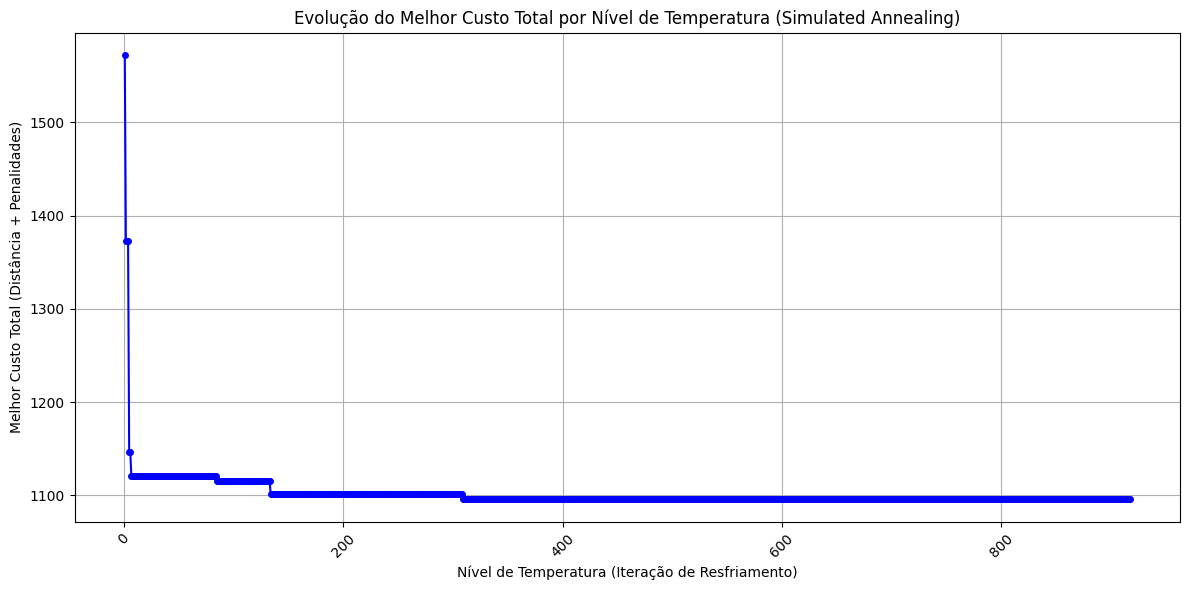

In [ ]:
# Criar um gráfico da evolução do melhor custo para o Simulated Annealing
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(historico_custos_sa) + 1), historico_custos_sa, marker='o', linestyle='-', markersize=4, color='blue')
plt.title('Evolução do Melhor Custo Total por Nível de Temperatura (Simulated Annealing)')
plt.xlabel('Nível de Temperatura (Iteração de Resfriamento)')
plt.ylabel('Melhor Custo Total (Distância + Penalidades)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3.5 Visualização da Rota Otimizada pelo Simulated Annealing

Vamos visualizar a melhor rota encontrada pelo Simulated Annealing usando as funções de plotagem já definidas.

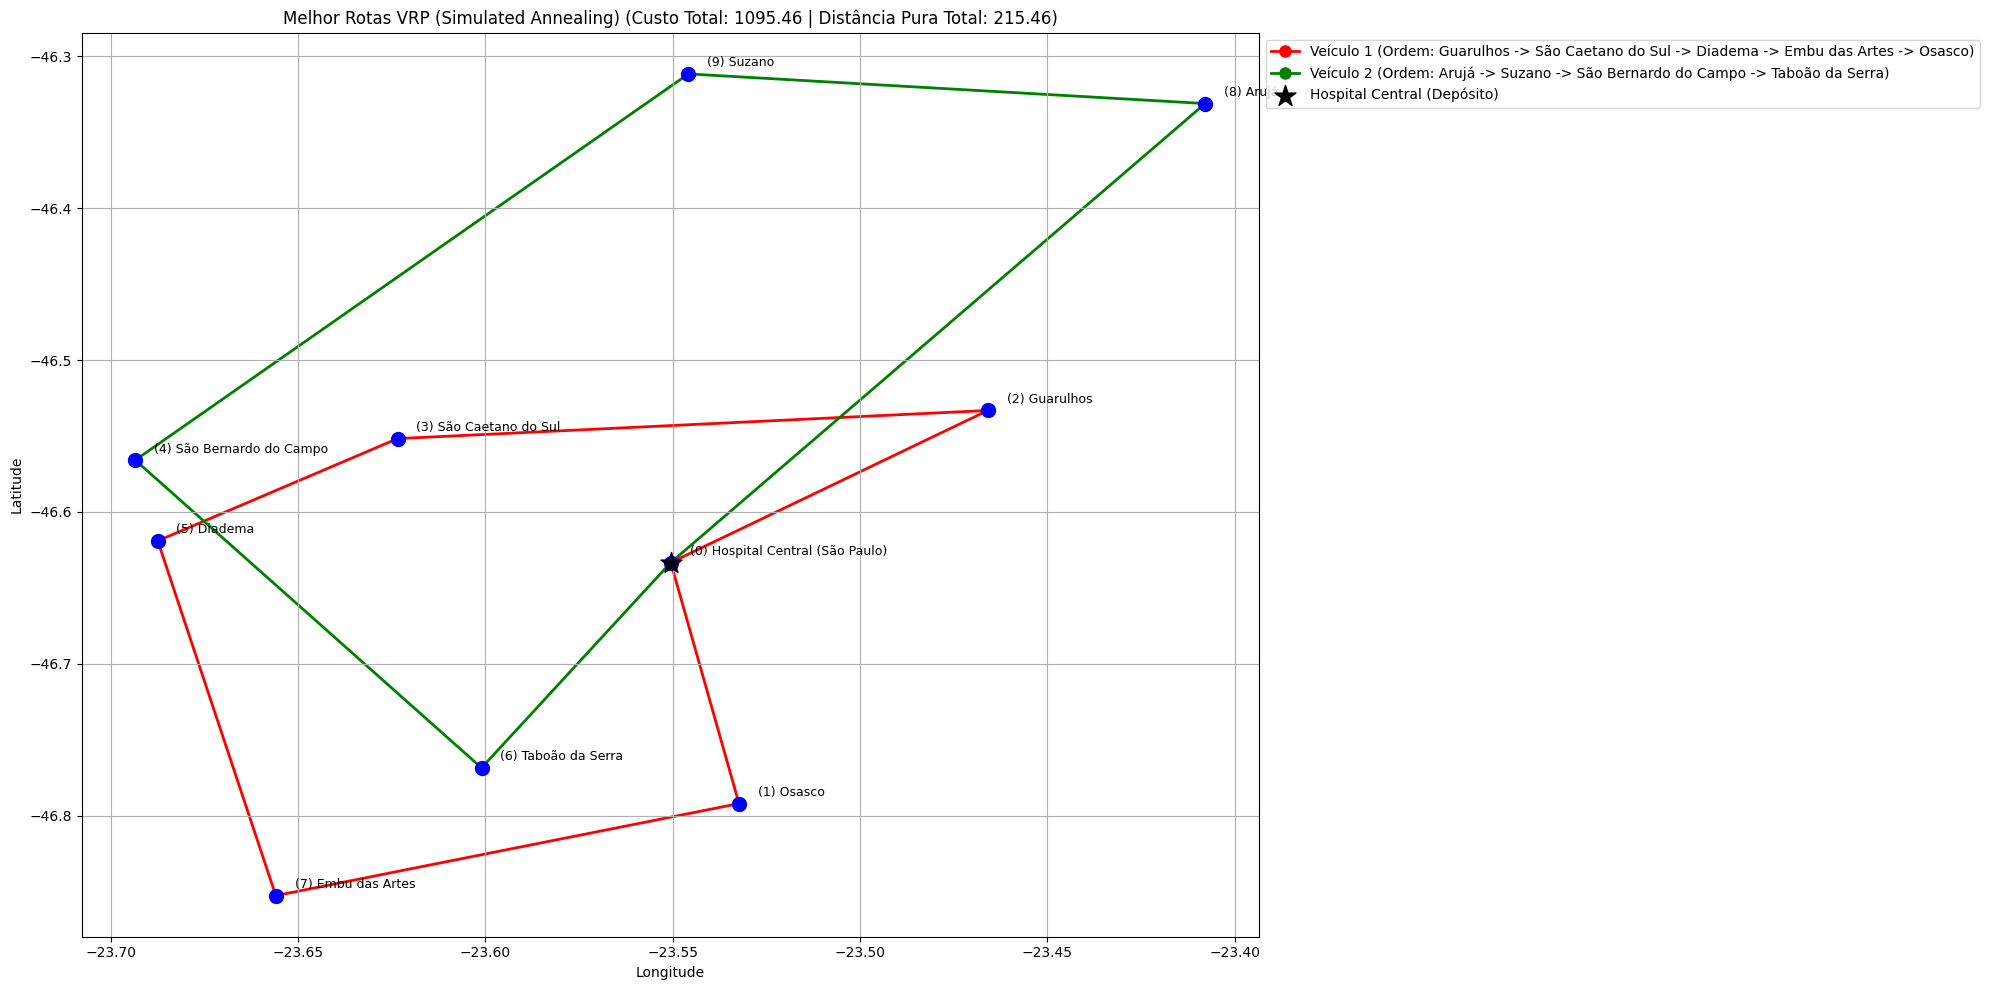

In [ ]:
# Visualizar a melhor rota VRP encontrada pelo Simulated Annealing
visualizar_rota_vrp(melhor_rota_sa, cidades, f"Melhor Rotas VRP (Simulated Annealing) (Custo Total: {menor_custo_sa:.2f} | Distância Pura Total: {menor_distancia_pura_sa:.2f})")

# Visualizar a melhor rota VRP encontrada pelo Simulated Annealing no mapa interativo
mapa_rota_vrp_sa = visualizar_rota_mapa_vrp(melhor_rota_sa, cidades,
                                         f"Melhor Rotas VRP (Simulated Annealing) (Custo Total: {menor_custo_sa:.2f} km | Distância Pura Total: {menor_distancia_pura_sa:.2f} km)")

# Exibir o mapa
mapa_rota_vrp_sa
